In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
len(words)

32033

In [5]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [70]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)

In [71]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [11]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [12]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [230]:
# Create a 2d dimensional embedding space
C = torch.randn((27, 2))
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [42]:
# hidden layer: 6 inputs, 100 neurons
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [43]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # use emb.view to manipulate shape of embedding array into one suitable for our nn, emb.shape[0] == -1
h.shape

torch.Size([32, 100])

In [44]:
# concatenating the 6 inputs that represent the 2d embedding of each character in our 3 character context window
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape # can't generalize
torch.cat(torch.unbind(emb, 1), 1).shape # inside exactly same as above

torch.Size([32, 6])

In [45]:
# Output layer: 100 inputs from prev layer, and 27 outputs representing 27 possible next characters
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [46]:
logits = h @ W2 + b2

In [47]:
logits.shape

torch.Size([32, 27])

In [50]:
counts = logits.exp()

In [51]:
prob = counts / counts.sum(1, keepdims=True)

In [52]:
prob.shape

torch.Size([32, 27])

In [54]:
# calculating loss
loss = - prob[torch.arange(32), Y].log().mean()
loss

tensor(15.5450)

In [231]:
# SUMMARY
X.shape, Y.shape # dataset
embed_dim = 27
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, embed_dim), generator=g) # [num characters, embed dim]
W1 = torch.randn((embed_dim*block_size, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [232]:
sum(p.nelement() for p in parameters) # number of parameters in total

22556

In [233]:
for p in parameters:
    p.requires_grad = True

In [234]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [235]:
lri = []
lossi = []
stepi = []

In [246]:
for i in range(50000):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # Forward Pass
    emb = C[Xtr[ix]] # (32, 3, 2) # so we are indexing into a minibatch of 32 examples at a time rather than 200k 
    h = torch.tanh(emb.view(-1, 81) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdims=True)
    # loss = - prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Ytr[ix]) # does the same as above, use mini batches too
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    lossi.append(loss.log10().item())
    stepi.append(i)
                 
print(loss.item())

2.3577370643615723


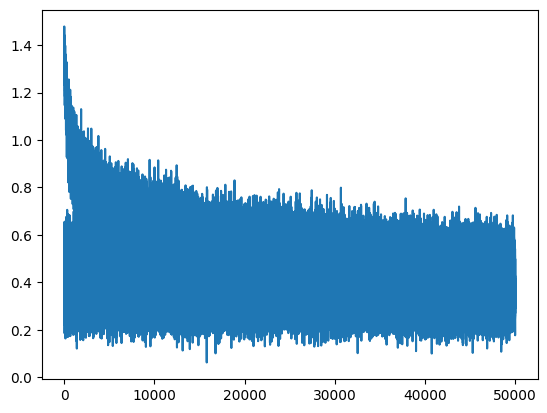

In [247]:
plt.plot(stepi, lossi)

In [248]:
emb = C[Xdev] # (32, 3, 2) # so we are indexing into a minibatch of 32 examples at a time rather than 200k 
h = torch.tanh(emb.view(-1, 81) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1411, grad_fn=<NllLossBackward0>)

In [249]:
emb = C[Xtr] # (32, 3, 2) # so we are indexing into a minibatch of 32 examples at a time rather than 200k 
h = torch.tanh(emb.view(-1, 81) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0563, grad_fn=<NllLossBackward0>)

In [183]:
# minibatches
torch.randint(0, X.shape[0], (32,)) # generates numbers between 0 and number of training examples in our data set, and it creates 32 of them
X.shape[0]

228146

In [164]:
# training split, dev/validation split, test split
# 80%, 10%, 10%
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [165]:
Xtr.shape, Ytr.shape # training data set

(torch.Size([182625, 3]), torch.Size([182625]))

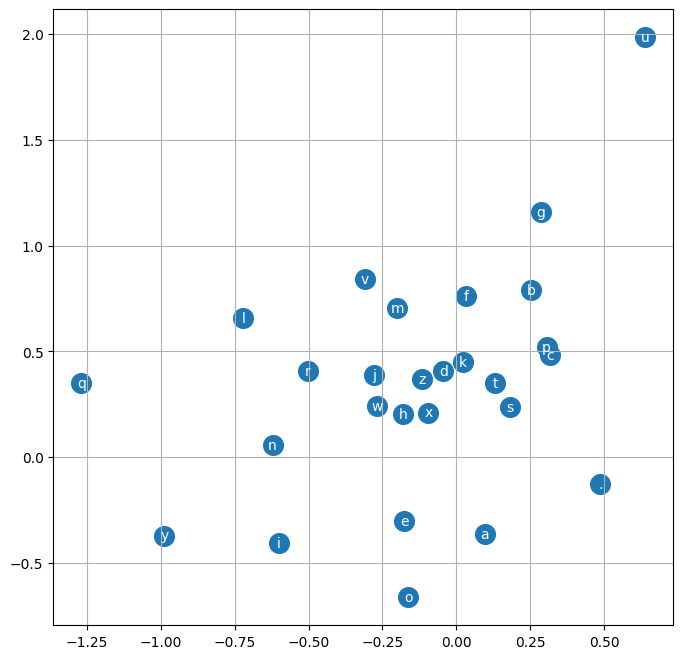

In [201]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [258]:
# ----------------------SUMMARY----------------------

# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

# Parameters and variables
V = len(stoi)
B = 3 # context length: how many characters do we take to predict the next one?
d = 27 # embedding dimension
H = 200 # number of neurons in hidden layer
N = 0 # number of training examples, dependent on block size

# build the dataset
def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * B
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

N = len(X)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [259]:
# defining nn
X.shape, Y.shape # dataset
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((V, d), generator=g) # [num characters, embed dim]
W1 = torch.randn((d*B, H), generator=g)
b1 = torch.randn(H, generator=g)
W2 = torch.randn((H, V), generator=g)
b2 = torch.randn(V, generator=g)
parameters = [C, W1, b1, W2, b2]
sum(p.nelement() for p in parameters) # number of parameters in total

22556

In [260]:
for p in parameters:
    p.requires_grad = True

In [261]:
# range of learning rates to find optimal lr and track stats
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lrs
lri = []
lossi = []
stepi = [] 

In [275]:
# Training 
for i in range(50000):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # Forward Pass
    emb = C[Xtr[ix]] # (32, 3, 2) # so we are indexing into a minibatch of 32 examples at a time rather than 200k 
    h = torch.tanh(emb.view(-1, d*B) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdims=True)
    # loss = - prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Ytr[ix]) # does the same as above, use mini batches too
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    lossi.append(loss.log10().item())
    stepi.append(i)
                 
print(loss.item())

2.155726909637451


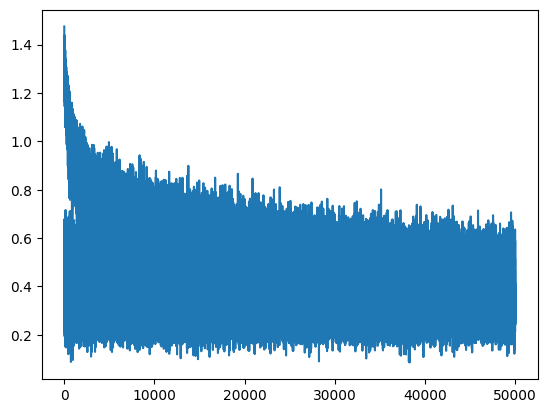

In [278]:
plt.plot(stepi, lossi)

In [276]:
# Evaluating Training vs Dev Loss
# dev
emb = C[Xdev] # (32, 3, 2) # so we are indexing into a minibatch of 32 examples at a time rather than 200k 
h = torch.tanh(emb.view(-1, 81) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1305, grad_fn=<NllLossBackward0>)

In [277]:
# training
emb = C[Xtr] # (32, 3, 2) # so we are indexing into a minibatch of 32 examples at a time rather than 200k 
h = torch.tanh(emb.view(-1, 81) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0341, grad_fn=<NllLossBackward0>)

In [279]:

torch.Size([1, 3, 10])
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmah.
ambrilli.
kemlee.
tatl.
skaad.
kenricee.
famesart.
kaeli.
nellara.
chaiivia.
legypshly.
pory.
quint.
shon.
malian.
quinte.
madiaryxia.
kaellinslee.
dae.
oin.
